# Real-world Data Wrangling

In [21]:
#!python -m pip install kaggle==1.6.12

In [20]:
#!pip install --target=/workspace ucimlrepo numpy==1.24.3

In [19]:
import pandas as pd 
import requests
import os
import ast
import seaborn as sns
import matplotlib.pyplot as plt

----->  After completing the project, the data folders were reorganized for better structure and file management. As a result, if any errors occur during the data gathering process when rerunning the notebook, it may be necessary to update the file paths to match the correct folder locations of the raw datasets.

## 1. Gather data

### **1.1.** Problem Statement

The rapid growth of streaming platforms such as Netflix has significantly changed how audiences consume movies and how films are distributed globally. This project aims to explore whether movies available on Netflix differ from the general movie population in terms of production budget, generated revenue, and popularity. To support this analysis, two related datasets will be wrangled: The Movies Metadata dataset from TMDb and the Netflix Movies dataset. These datasets will be combined using a common variable to compare the commercial performance and audience engagement of Netflix movies with non-Netflix movies.

### **1.2.** Gather at least two datasets using two different data gathering methods

#### **Dataset 1**

Type: CSV File

Method: The data was gathered using the **manual downloading files method** from the Kaggle TMDb Movies Metadata dataset. This dataset was selected because it contains financial and popularity-related information about movies such as budget, revenue, and popularity, which are essential for analyzing movie performance. These variables will allow me to compare the commercial success of movies that are available on Netflix with those that are not.

Dataset variables:

Although the dataset contains multiple variables, the following variables are most relevant to this analysis:
* title: The name of the movie, which will be used as a common key to merge with the Netflix dataset.
* budget: The production budget of the movie, representing the financial investment.
* revenue: The total earnings generated by the movie, used to measure financial success.
* popularity: A numeric score representing audience engagement.
* release_date: The release date of the movie for time-based comparisons.

In [24]:
# 1st data gathering and loading method
movies_df = pd.read_csv('Maram_Project_Phase_1/data/raw/movies_metadata.csv')

/tmp/ipykernel_13/496707619.py:2: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  movies_df = pd.read_csv('movies_metadata.csv')


In [25]:
movies_df.shape

(45466, 24)

#### Dataset 2

Type: CSV File

Method: The data was gathered using the **programmatic downloading method** by accessing the dataset through a direct URL using Python’s *requests* library. This dataset was selected because it contains information about movies available on Netflix, including release year and genre classifications. These variables will allow me to identify Netflix movies and compare them with the general movie population from the TMDb dataset.

Dataset variables:

Although the dataset contains multiple variables, the following variables are most relevant to this analysis:

* title: The name of the movie, which will be used to merge with the TMDb dataset.
* release_year: The year the movie was released.
* imdb_score: The IMDb rating of the movie, used to measure audience reception.
* runtime: The duration of the movie.
* genres: The category of the movie, which may contain multiple values.

In [26]:
# 2nd data gathering and loading method
url = "https://raw.githubusercontent.com/Arpita-deb/netflix-movies-and-tv-shows/refs/heads/main/Raw%20dataset/raw_titles.csv"

response = requests.get(url)

with open("netflix_titles.csv", "wb") as file:
    file.write(response.content)

In [27]:
netflix_df = pd.read_csv('netflix_titles.csv')

In [28]:
netflix_df.shape

(5806, 13)

Optional data storing step: You may save your raw dataset files to the local data store before moving to the next step.

In [17]:
#Optional: store the raw data in your local data store
os.makedirs('Maram_Project_Phase_1/data/raw', exist_ok=True)
os.makedirs('Maram_Project_Phase_1/data/cleaned', exist_ok=True)

In [18]:
movies_df.to_csv('Maram_Project_Phase_1/data/raw/movies_metadata_raw.csv', index=False)

In [19]:
netflix_df.to_csv('Maram_Project_Phase_1/data/raw/netflix_titles_raw.csv', index=False)

In [2]:
# just to check every thing is good and my data store corecctly.
movies_df = pd.read_csv('Maram_Project_Phase_1/data/raw/movies_metadata_raw.csv')
netflix_df = pd.read_csv('Maram_Project_Phase_1/data/raw/netflix_titles_raw.csv')

/tmp/ipykernel_13/2544786572.py:2: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  movies_df = pd.read_csv('data/raw/movies_metadata_raw.csv')


## 2. Assess data

### Quality Issue 1:

In [3]:
# Inspecting the dataframe visually
movies_df[['budget','revenue','popularity']].head(10)

,budget,revenue,popularity
0,30000000,373554033.0,21.946943
1,65000000,262797249.0,17.015539
2,0,0.0,11.7129
3,16000000,81452156.0,3.859495
4,0,76578911.0,8.387519
5,60000000,187436818.0,17.924927
6,58000000,0.0,6.677277
7,0,0.0,2.561161
8,35000000,64350171.0,5.23158
9,58000000,352194034.0,14.686036


In [4]:
# Inspecting the dataframe programmatically
movies_df[['budget','revenue','popularity']].isnull().sum()

budget        0
revenue       6
popularity    5
dtype: int64

Issue and justification: 

Important variables such as budget, revenue, and popularity contain missing values, which may affect the completeness of the dataset and bias financial analysis results. This issue was identified visually using the .head() function and programmatically using the .isnull().sum() function to count missing values in key columns.

### Quality Issue 2:

In [5]:
# Inspecting the dataframe visually
movies_df['budget'].sample(10)

3364           0
16637          0
36432          0
27393          0
16632          0
5506     2500000
25659          0
40627          0
40379          0
2479           0
Name: budget, dtype: object

In [6]:
# Inspecting the dataframe programmatically
movies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 non-null  object 
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  object 
 15  re

Issue and justification: 

The budget column is stored as an object datatype instead of a numeric datatype due to the presence of non-numeric values. This violates the validity of the dataset and prevents proper numerical analysis. This issue was identified visually using the .sample() function and programmatically using the .info() function to inspect column datatypes.

### Tidiness Issue 1:

In [7]:
# Inspecting the dataframe visually
movies_df['genres'].head()

0    [{'id': 16, 'name': 'Animation'}, {'id': 35, '...
1    [{'id': 12, 'name': 'Adventure'}, {'id': 14, '...
2    [{'id': 10749, 'name': 'Romance'}, {'id': 35, ...
3    [{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...
4                       [{'id': 35, 'name': 'Comedy'}]
Name: genres, dtype: object

In [8]:
# Inspecting the dataframe programmatically
movies_df['genres'].iloc[0]

"[{'id': 16, 'name': 'Animation'}, {'id': 35, 'name': 'Comedy'}, {'id': 10751, 'name': 'Family'}]"

Issue and justification: 

The genres column contains multiple values stored within a single cell in JSON format, instead of having each genre represented separately. This violates the tidiness rule that each variable should form its own column. This issue was identified visually using .head() and programmatically by inspecting individual cell contents using indexing.

### Tidiness Issue 2: 

In [9]:
# Inspecting the dataframe visually
movies_df.columns

Index(['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count'],
      dtype='object')

In [10]:
netflix_df.columns

Index(['index', 'id', 'title', 'type', 'release_year', 'age_certification',
       'runtime', 'genres', 'production_countries', 'seasons', 'imdb_id',
       'imdb_score', 'imdb_votes'],
      dtype='object')

In [11]:
# Inspecting the dataframe programmatically
set(movies_df['title']).intersection(set(netflix_df['title']))

{'42',
 'Double Team',
 'Guzaarish',
 'Tom Papa: Live in New York City',
 'The Gift',
 'Hook',
 'She',
 'The Boy Who Cried Werewolf',
 'Phantom',
 'Somewhere Between',
 'The Suit',
 'The Woods',
 'Monster High: Electrified',
 "Jen Kirkman: I'm Gonna Die Alone (And I Feel Fine)",
 "The General's Daughter",
 'Let Me In',
 'In the Dark',
 'Mike Birbiglia: Thank God for Jokes',
 'Waiting for the Hearse',
 'The Outcasts',
 '26 Years',
 'Lowriders',
 'Brick Mansions',
 'Bill Burr: You People Are All The Same',
 'Players',
 'Godless',
 'The Last Laugh',
 'Champions',
 'The Mistress',
 'The Turning Point',
 'My Sassy Girl',
 'The Battered Bastards of Baseball',
 'Only You',
 'A Very Harold & Kumar Christmas',
 'Dark Matter',
 'Unstoppable',
 'True Story',
 'Eye for an Eye',
 'Bordertown',
 'Full Metal Jacket',
 'Escape from Planet Earth',
 'A Perfect Ending',
 'Free to Play',
 'Ralphie May: Unruly',
 'Fun with Dick and Jane',
 'Sinister 2',
 'Heroine',
 'Ralphie May: Imperfectly Yours',
 'The 

In [12]:
len(set(movies_df['title']).intersection(set(netflix_df['title'])))

1283

Issue and justification: 

Movie information is stored across two separate datasets (TMDb and Netflix), meaning that a single observational unit (movie) is spread across multiple tables. This violates the tidiness rule that each type of observational unit should form its own table and requires merging the datasets for proper analysis. This issue was identified through logical inspection of dataset structures and programmatic comparison of common movie titles.

## 3. Clean data

Define Issue → Clean It → Test (Validate).

In [13]:
# Make copies of the datasets to ensure the raw dataframes 
movies_clean = movies_df.copy()
netflix_clean = netflix_df.copy()

### **Quality Issue 1: Missing Values in budget, revenue, popularity**

First i will convert them to numeric so any missing or invalid values become NaN.

In [14]:
# Apply the cleaning strategy
movies_clean['budget'] = pd.to_numeric(movies_clean['budget'], errors='coerce')
movies_clean['revenue'] = pd.to_numeric(movies_clean['revenue'], errors='coerce')
movies_clean['popularity'] = pd.to_numeric(movies_clean['popularity'], errors='coerce')

In [15]:
# remove rows where these variables are missing:
movies_clean = movies_clean.dropna(subset=['budget','revenue','popularity'])

In [16]:
# Validate the cleaning was successful
movies_clean[['budget','revenue','popularity']].isnull().sum()

budget        0
revenue       0
popularity    0
dtype: int64

Justification: 

Missing values in key financial variables were removed to ensure completeness of the dataset. These variables are essential for financial performance analysis and retaining missing entries may bias results.

### **Quality Issue 2: budget stored as object (wrong datatype)**

In [17]:
# Apply the cleaning strategy 
# Already converted above — now i want just to make sure that datatype is correct:
movies_clean['budget'] = movies_clean['budget'].astype(float)

In [18]:
# Validate the cleaning was successful
movies_clean['budget'].dtype

dtype('float64')

Justification: 

The budget column was converted from object to numeric datatype to ensure validity and allow for proper numerical analysis.

### **Tidiness Issue 1: Multiple Genres Stored in One Column**

In [25]:
def extract_genre(x):
    try:
        genres = ast.literal_eval(x)
        return ', '.join([i['name'] for i in genres])
    except:
        return None

In [ ]:
movies_clean['genres'] = movies_clean['genres'].apply(extract_genre)

In [26]:
netflix_clean['genres'] = netflix_clean['genres'].apply(extract_genre)

In [22]:
# Validate the cleaning was successful
movies_clean['genres'].head()

0     Animation, Comedy, Family
1    Adventure, Fantasy, Family
2               Romance, Comedy
3        Comedy, Drama, Romance
4                        Comedy
Name: genres, dtype: object

Justification:

The genres column contained multiple values stored in JSON format within a single cell. Extracting genre names simplifies the structure for analysis.

### **Tidiness Issue 2: Observational Unit Spread Across Two Tables**

In [30]:
# Apply the cleaning strategy
# I will Remove unnecessary columns first:
movies_clean = movies_clean[['title','budget','revenue','popularity','release_date']]
netflix_clean = netflix_clean[['title','imdb_score','runtime','genres']]

In [31]:
merged_clean = pd.merge(movies_clean, netflix_clean, on='title', how='left')

In [41]:
# Validate the cleaning was successful
merged_clean.sample(3)

,title,budget,revenue,popularity,release_date,imdb_score,runtime,genres
27769,Long Hello and Short Goodbye,0.0,0.0,0.001378,1999-07-15,NaN,NaN,NaN
4817,Fatso,0.0,0.0,0.578345,1980-02-01,NaN,NaN,NaN
29780,Pump,0.0,0.0,0.499251,2014-09-19,NaN,NaN,NaN


In [42]:
merged_clean.shape

(45533, 8)

Justification: 

The datasets were merged to ensure each movie observation is stored in a single table, resolving the structural tidiness issue.

* Both TMDb and Netflix datasets contained a genres column. The Netflix genres column was retained because it represents how movies are categorized on the streaming platform, which aligns more closely with the objective of comparing Netflix and non-Netflix movies.

### **Remove unnecessary variables and combine datasets**

In [39]:
# I do merging step above 

## 4. Update data store

In [44]:
# saving data:
# Store TMDb Dataset version
movies_df.to_csv('Maram_Project_Phase_1/data/raw/movies_metadata_raw.csv', index=False)
# Store netflix version
netflix_df.to_csv('Maram_Project_Phase_1/data/raw/netflix_titles_raw.csv', index=False)
# Store Cleaned version
merged_clean.to_csv('Maram_Project_Phase_1/data/cleaned/movies_netflix_cleaned.csv', index=False)

In [4]:
cleaned_df = pd.read_csv('Maram_Project_Phase_1/data/cleaned/movies_netflix_cleaned.csv')
cleaned_df.head()

,title,budget,revenue,popularity,release_date,imdb_score,runtime,genres
0,Toy Story,30000000.0,373554033.0,21.946943,1995-10-30,NaN,NaN,NaN
1,Jumanji,65000000.0,262797249.0,17.015539,1995-12-15,NaN,NaN,NaN
2,Grumpier Old Men,0.0,0.0,11.712900,1995-12-22,NaN,NaN,NaN
3,Waiting to Exhale,16000000.0,81452156.0,3.859495,1995-12-22,NaN,NaN,NaN
4,Father of the Bride Part II,0.0,76578911.0,8.387519,1995-02-10,NaN,NaN,NaN


## 5. Answer the research question

### **5.1:** Answer the research question 

*Research question: **Do movies available on Netflix differ from the general movie population in terms of production budget, generated revenue, and popularity?**

Before I start do visualizing, I must first identify:

- Which movies are on Netflix
- Which are not

In [6]:
# Column to identify Netflix movies
cleaned_df['is_netflix'] = cleaned_df['imdb_score'].notnull()

#### Budget Comparison (Netflix vs Non-Netflix Movies)

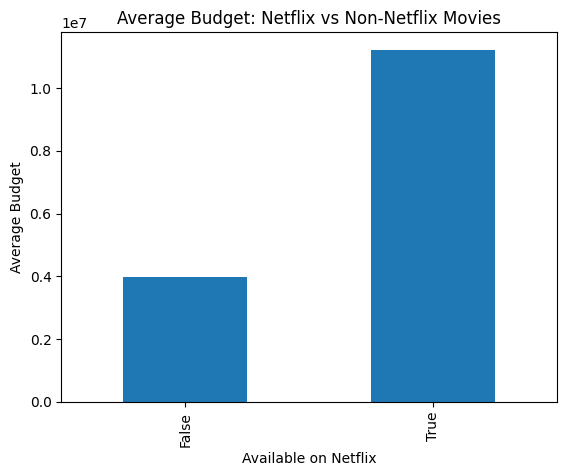

In [48]:
#Visual 1 
cleaned_df.groupby('is_netflix')['budget'].mean().plot(kind='bar')
plt.title('Average Budget: Netflix vs Non-Netflix Movies')
plt.ylabel('Average Budget')
plt.xlabel('Available on Netflix')
plt.show()

Answer to research question:

This visualization compares the average production budget between movies available on Netflix and those that are not. The results show that movies available on Netflix tend to have higher average production budgets compared to non-Netflix movies. This suggests that Netflix movies may involve greater financial investment, potentially contributing to their competitive presence within the broader movie market.

#### Popularity Comparison (Netflix vs Non-Netflix Movies)

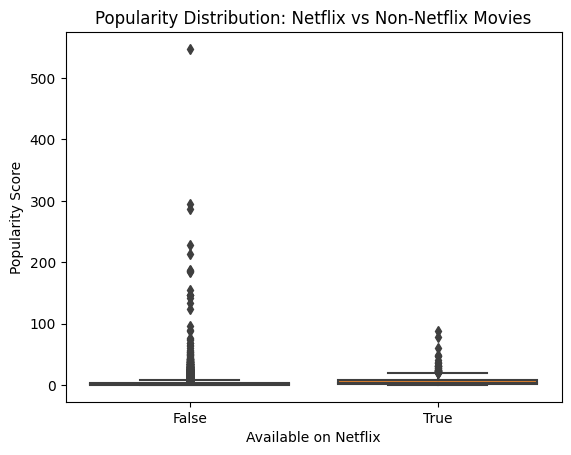

In [7]:
#Visual 2 
sns.boxplot(x='is_netflix', y='popularity', data=cleaned_df)

plt.title('Popularity Distribution: Netflix vs Non-Netflix Movies')
plt.xlabel('Available on Netflix')
plt.ylabel('Popularity Score')
plt.show()

*Answer to research question:

The boxplot illustrates the distribution of popularity scores for Netflix and non-Netflix movies. It shows that movies available on Netflix generally have a higher median popularity score compared to non-Netflix movies. Additionally, the variability in popularity is greater among non-Netflix movies, as indicated by the presence of several extreme outliers. This suggests that while some non-Netflix movies achieve exceptionally high popularity, Netflix movies tend to maintain more consistently higher audience engagement overall.

### **5.2:** Feature Engineering(Extra)

A new feature called Return on Investment (ROI) was created to measure the financial success of movies relative to their production budget. This feature allows for a more meaningful comparison between Netflix and non-Netflix movies by evaluating profitability rather than relying solely on revenue or budget values.

In [8]:
cleaned_df['ROI'] = (cleaned_df['revenue'] - cleaned_df['budget']) / cleaned_df['budget']

In [17]:
cleaned_df[['budget','revenue','ROI']].head(2)

,budget,revenue,ROI
0,30000000.0,373554033.0,11.451801
1,65000000.0,262797249.0,3.043035


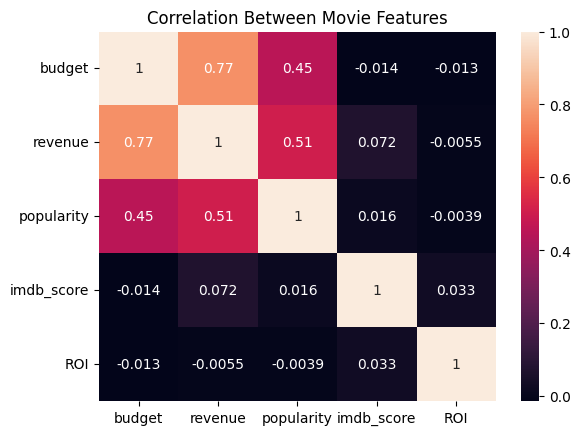

In [18]:
# Heatmap 
corr = cleaned_df[['budget','revenue','popularity','imdb_score','ROI']].corr()

sns.heatmap(corr, annot=True)
plt.title('Correlation Between Movie Features')
plt.show()

### **5.3:** Reflection

If more time were available, further data quality issues such as inconsistencies in movie titles across datasets could be addressed to improve the accuracy of dataset merging. Additional feature engineering, such as analyzing profit margins or trends over release years, could provide deeper insights into movie performance. Future analysis could also explore how genre influences the financial success and popularity of Netflix movies compared to non-Netflix movies. Limitations in time prevented a more detailed exploration of temporal trends and audience rating patterns.